# ThF⁺ isotopologues and the two-photon operator, with `heff`

We now compare ²³²Th¹⁹F⁺, ²²⁹Th¹⁹F⁺ and ²²⁷Th¹⁹F⁺ in the X ³Δ₁ ground
vibronic state, J = 1–4. Changing the thorium isotope changes the nuclear spin.
²³²Th is spin-0, so only ¹⁹F contributes nuclear hyperfine structure. Its panels
use the one-spin basis `|J, Ω, F, m_F⟩` (`KET_C`, half-integer `F`/`m_F`,
F = J ± ½ from ¹⁹F alone). ²²⁹Th (I = 5/2) and ²²⁷Th (I = 1/2) add a second coupled
nuclear spin, giving the two-spin basis `|((J I_Th) F₁, I_F) F, m_F⟩`
(`KET_C2`, integer `F`/`m_F`).

We construct the coupled bases and term matrices directly. For the TOML
workflow, start with the repository [README](../README.md). The
separate [three-isotope field plots](../results/thf-fields-2026-09-08/README.md)
use larger exploratory bases and document their own parameter sets.

The code prints the conventions using `pset.conventions.stamp()`.
The [232Th tutorial](ThF_plus_X3Delta1_Tutorial.ipynb) defines
`n_hat`, `ef_rule`, `zeeman_sign`, `zeeman_energy`, `dg_def`, `edm_factor`,
`dipole_origin`, `formalism`. This notebook adds four conventions:
`quadrupole_convention` (B&C's q₀-is-negative-EFG sign, single-valued),
`eqq2_norm` (B&C (9.52)'s q = ±2 normalisation, `'bc_9p52_q2'`, the only
implemented value; `'petrov2018_eq23'` raises, OPEN-17), `two_photon_norm`
(`'bc_5p142_reduced'`, unit reduced one-photon elements per channel), and the
`version` tag itself, `'thf-v2'`.

No Th hyperfine constant has been measured for a ThF⁺ isotopologue ([TH] §2.1,
gap G5). The ²²⁹ magnetic hyperfine value is an ab-initio scale with an
unresolved sign choice; its quadrupole values are uncalibrated sensitivity
placeholders. The native ²²⁷ value is a Schmidt stress test, while the field
plots separately show the Minkov nuclear-theory alternative. These statuses
limit what we can infer from the figures. Tests check code identities and
regressions; they cannot determine these unknown molecular inputs.

References used below are the [Hamiltonian reference][HAM],
[thorium hyperfine digest][TH], [two-photon digest][2γ], and
[isotopologue model specification][SPEC-v2].

[HAM]: ../docs/thf-plus-x3delta1-effective-hamiltonian.md
[TH]: ../docs/digest-literature-th-hyperfine.md
[2γ]: ../docs/digest-literature-two-photon.md
[SPEC-v2]: ../docs/design/2026-09-05-heff-v2-isotopologues-two-photon.md

## 1. The basis

`|J, Ω, F₁, F, m_F⟩` with `F₁ = J + I_Th` (the inner coupling) and
`F = F₁ + I_F` (¹⁹F the outer spin). We couple thorium first ([SPEC-v2] §2.1,
[HAM] §9). At ²³²Th's `I_Th = 0`, this reduces exactly to the one-spin
`F = J + I_F` basis (`KET_C`), including the `REGISTRY_C2` matrix elements.
`thf_spec('232')` therefore returns the same object as `thf_spec()`.

Petrov 2018 uses the fully
decoupled product basis `|J, m_J⟩|I_Th, m_1⟩|I_F, m_2⟩` ([SPEC-v2] §2.1). The
coupled `F₁` scheme is used here because it is what B&C's spectator theorems
((5.172), (5.174), (5.186)) are written for, and because `F₁` turns out to be
an approximately good quantum number. [TH] §4.5 finds `ΔF₁ = ±1` mixing at
the 25 kHz level against 190–2670 MHz `F₁` spacings. This makes `F₁` a useful
label for interpreting the levels.

The dimension closed form ([SPEC-v2] §2.2): `(2I_Th+1)(2I_F+1) Σ_{J=1}^{J_max}
2(2J+1)` for the two-spin case; `(2I_F+1) Σ 2(2J+1)` for ²³² (`I_Th = 0`).

In [1]:
import numpy as np

import heff
from heff import (block_by_mF, build_term_matrices, ctx_from, enumerate_kets,
                  g_factors, hamiltonian, label_lines, line_strengths,
                  sweep, terms_for_case, thf_spec, thf_v2)
from heff.elements_c2 import REGISTRY_C2, j_convergence
from heff.spec import Spin, StateSpec
from heff.twophoton import two_photon_line_strengths

import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 90
np.set_printoptions(precision=6, suppress=True, linewidth=120)

ISOTOPOLOGUES = ('232', '229', '227')
J_MAX = 4

pset229 = thf_v2('229')
print('conventions.stamp():')
for key, val in pset229.conventions.stamp().items():
    print(f"  {key:<22s} {val}")


def load(iso, J_max=J_MAX, mF=None):
    """One isotopologue's field-free basis, one signed-m_F block, the term
    matrices for it, and the Blocking of the FULL basis (so a caller can look
    up dimensions of other blocks too). '229'/'227' build on KET_C2 through
    REGISTRY_C2; '232' builds on the v1 KET_C basis through the default
    registry. The same helper handles both dtypes so the later cells can make
    like-for-like comparisons.
    """
    spec = thf_spec(iso, J_max=J_max)
    kets = enumerate_kets(spec)
    blocks = block_by_mF(kets)
    if mF is None:
        mF = 0.5 if iso == '232' else 0.0
    sub = kets[blocks.index[mF]]
    pset = thf_v2(iso)
    ctx = ctx_from(spec, pset)
    if iso == '232':
        tm = build_term_matrices(sub, ctx)
    else:
        tm = build_term_matrices(sub, ctx, case='c2', registry=REGISTRY_C2)
    return sub, blocks, ctx, tm


print()
for iso in ISOTOPOLOGUES:
    kets, blocks, ctx, tm = load(iso)
    I_Th = ctx.spins[0].I if ctx.spins else 0.0
    tag = 'v1 KET_C basis' if iso == '232' else 'KET_C2 basis'
    print(f"{iso}ThF+  total dim = {blocks.n_total}  I_Th = {I_Th}  ({tag})")
    print(f"  {len(blocks.labels)} signed-m_F blocks, sizes "
          f"{ {lab: len(ix) for lab, ix in sorted(blocks.index.items())} }")

conventions.stamp():
  n_hat                  F_to_Th
  ef_rule                brown1975
  zeeman_sign            plus_Gpar
  zeeman_energy          E_minus_g_muB_B_mF
  dg_def                 Delta
  edm_factor             ng
  dipole_origin          center_of_mass
  formalism              R2
  quadrupole_convention  bc_q0_is_negative_efg
  eqq2_norm              bc_9p52_q2
  two_photon_norm        bc_5p142_reduced
  version                thf-v2



232ThF+  total dim = 96  I_Th = 0.0  (v1 KET_C basis)
  10 signed-m_F blocks, sizes {-4.5: 2, -3.5: 6, -2.5: 10, -1.5: 14, -0.5: 16, 0.5: 16, 1.5: 14, 2.5: 10, 3.5: 6, 4.5: 2}


229ThF+  total dim = 576  I_Th = 2.5  (KET_C2 basis)
  15 signed-m_F blocks, sizes {-7.0: 2, -6.0: 8, -5.0: 18, -4.0: 32, -3.0: 48, -2.0: 64, -1.0: 76, 0.0: 80, 1.0: 76, 2.0: 64, 3.0: 48, 4.0: 32, 5.0: 18, 6.0: 8, 7.0: 2}
227ThF+  total dim = 192  I_Th = 0.5  (KET_C2 basis)
  11 signed-m_F blocks, sizes {-5.0: 2, -4.0: 8, -3.0: 16, -2.0: 24, -1.0: 30, 0.0: 32, 1.0: 30, 2.0: 24, 3.0: 16, 4.0: 8, 5.0: 2}


## 2. The term catalogue and its matrix elements

`terms_for_case('c2', registry=REGISTRY_C2)` for ²²⁹/²²⁷; the default
`terms_for_case('c')` for ²³². Every term below is registered with its
selection rules (`Rules`) and a citation (`term.cite`). The printout shows
both. The formulas below follow [HAM], with the corresponding B&C equations.

The one-spin terms are ([HAM] §2, `heff/elements_c.py`):

- Rotation + centrifugal (§2.1): `H_rot = B₀ J(J+1) − D₀ [J(J+1)]²`,
  diagonal.
- Ω-doubling (§2.3, Ng Eq. C.3): off-diagonal element between `Ω = ±1` at
  fixed `J`, `+ω_ef J(J+1)/4`; splitting `ω_ef J(J+1)/2`. Ng's own printed
  operator carries an extra `(−1)^J` prefactor on this element; `heff` uses
  the J-independent sign that puts e below f at every J ([HAM] §2.3). Both give the identical
  physical splitting law, `ω_ef J(J+1)/2`, and only the J-dependent phase of
  the off-diagonal element differs.
- ¹⁹F hyperfine, ΔJ = 0 (§2.4, B&C (9.50)): diagonal,
  `A∥ [F(F+1) − I(I+1) − J(J+1)] / [2J(J+1)]`.
- ¹⁹F hyperfine, ΔJ = ±1 (§2.5, B&C (9.51)): off-diagonal in `J`, same
  `A∥`, dropped by Ng but above the kHz floor.
- Nuclear spin–rotation c_I (§2.6, B&C (8.7)/(8.20)):
  `c_I [F(F+1) − I(I+1) − J(J+1)] / 2`.
- Stark (§2.7): `−n̂_sign · d_mf E_z` × the rank-1 axial geometry
  (`elements_c.dipole_geometry`), `Δm_F = 0`, parity-odd.
- Zeeman (§2.8, sign corrected from Ng Eq. C.6): `+μ_B B·G·J` with the
  body-frame tensor `G = diag(G_xx, G_yy, G_zz)`, one term per component. The
  axial piece is `+G_zz μ_B Ω (J·n̂)(n̂·B)`; the perpendicular pair carries
  `G_perp = (G_xx + G_yy)/2` on `B·J − (B·n̂)(J·n̂)` and
  `G_Delta = (G_xx − G_yy)/2` on the ΔΩ = ±2 channel.
- Nuclear Zeeman, PT-odd EDM and scalar–pseudoscalar (§2.8, §2.12): opt-in,
  zero by default.

The two-spin terms use `axial_geometry` ([HAM] §9, `heff/elements_c2.py`).
Each element below follows the two-spectator chain
B&C (5.172) + (5.174) twice + (5.186) at the required rank and component,
or adapts a one-spin formula:

```
<J',Om',F1',F',m'| T^k_p(molecule-frame, component q) |J,Om,F1,F,m>
  = (-1)^(F'-m') ( F'  k  F ; -m'  p  m )                                 <- (5.172)
  x (-1)^(F+F1'+k+I_F) sqrt((2F'+1)(2F+1)) { F1  F  I_F ; F' F1' k }      <- (5.174), I_F spectator
  x (-1)^(F1+J'+k+I_Th) sqrt((2F1'+1)(2F1+1)) { J F1 I_Th ; F1' J' k }    <- (5.174), I_Th spectator
  x (-1)^(J'-Om') sqrt((2J'+1)(2J+1)) ( J' k J ; -Om' q Om )              <- (5.186)
```

with `q = Om' − Om`, `Δm_F` forced to `p` by the first 3j. [HAM] §9.1: this
reduces analytically to the one-spin element at `I_Th = 0`, an identity, not an
approximation.

- Five v1 diagonal-in-`F₁` terms (rotation, centrifugal, Ω-doubling,
  the two PT-odd terms) are the v1 formulas unchanged (§9.2, B&C (5.176):
  operators built from `J`/`Ω` alone are diagonal in `F₁`, `F`, `m_F`).
- `hyperfine_A_par_Th`, `hyperfine_A_par_Th_dJ1`, `spin_rotation_cI_Th`
  (§9.2 substitution table): the v1 `elements_c.hyperfine_A_par` /
  `hyperfine_A_par_dJ1` / `spin_rotation_cI` formulas with `(I, F) → (I_Th,
  F₁)` (B&C (9.50)/(9.51)/(8.20)), with `I_Th`/`F₁` in place
  of `I`/`F`.
- `zeeman_nuclear_Th` (§9.2.1): the one Th operator the substitution rule
  does *not* cover. It is a lab-frame rank-1 operator and uses the
  two-spectator chain at `k = 1`.
- `hyperfine_A_par_F`, `hyperfine_A_par_F_dJ1`, `spin_rotation_cI_F`
  (§9.3): the ¹⁹F operators recoupled with `I_Th` now a spectator, with `ΔF₁ =
  0, ±1` (¹⁹F is the *outer* spin, so B&C (5.176) does not apply to it).
- `quadrupole_eQq0_Th`, `quadrupole_eQq2_Th` (§9.4, B&C (9.52)/(9.53)):
  the Th electric quadrupole, `q = 0` diagonal and `q = ±2` mixing `Ω = ±1`.
  Structurally absent (not zero) for `I_Th < 1`, i.e. for ²²⁷Th and ²³²Th.

In [2]:
print(f"{'case c (v1)':-^100}")
for t in terms_for_case('c'):
    print(f"{t.name:28s} param={str(t.param):26s} dJ={t.rules.dJ} dOm={t.rules.dOm} dF={t.rules.dF}")

print()
print(f"{'case c2 (v2)':-^100}")
for t in terms_for_case('c2', registry=REGISTRY_C2):
    dF1 = t.rules.dF1
    print(f"{t.name:28s} param={str(t.param):26s} dJ={t.rules.dJ} dOm={t.rules.dOm} "
          f"dF1={dF1} dF={t.rules.dF}")

--------------------------------------------case c (v1)---------------------------------------------
centrifugal                  param=('D0',)                    dJ=(0,) dOm=(0.0,) dF=(0,)
hyperfine_A_par              param=('A_par',)                 dJ=(0,) dOm=(0.0,) dF=(0,)
hyperfine_A_par_dJ1          param=('A_par',)                 dJ=(-1, 1) dOm=(0.0,) dF=(0,)
omega_doubling               param=('omega_ef',)              dJ=(0,) dOm=(-2.0, 2.0) dF=(0,)
pt_odd_edm                   param=('d_e', 'E_eff')           dJ=(0,) dOm=(0.0,) dF=(0,)
pt_odd_scalar_pseudoscalar   param=('W_TP', 'k_TP')           dJ=(0,) dOm=(0.0,) dF=(0,)
rotation                     param=('B0',)                    dJ=(0,) dOm=(0.0,) dF=(0,)
spin_rotation_cI             param=('c_I',)                   dJ=(0,) dOm=(0.0,) dF=(0,)
stark_z                      param=('d_mf', 'E_z')            dJ=(-1, 0, 1) dOm=(0.0,) dF=(-1, 0, 1)
zeeman_Gxx                   param=('G_xx', 'B_z')            dJ=(-1, 0, 1) dO

## 3. ²³²ThF⁺ field-free level diagram

The v1 basis, no Th hyperfine. Per J, referred to `B₀ J(J+1)`: the ¹⁹F
hyperfine (`(3/4)|A∥| = 15.07 MHz` at J = 1, [HAM] §2.4) and the Ω-doubling
(`ω_ef J(J+1)/2`, [HAM] §2.3). `A_par` is measured (Ng 2022 Table I);
`omega_ef` is measured (Ng 2022 Table I). Both are carried unchanged by
`thf_v2('232')` from `thf_v1()`.

e/f labels: the upper Ω-doublet component has parity `−(−1)^J` at every
J. Equivalently, f lies `ω_ef J(J+1)/2` above e, uniformly in J (Brown 1975
convention; [HAM] §2.3, OPEN-2). The a ¹Σ⁺ state 314 cm⁻¹ above carries only
e levels, so it mixes with the ³Δ₁ e component alone and pushes it down. Here
parity refers to the eigenstate's parity, while the e/f label includes the
J-dependent convention. Thus upper-state parity `−(−1)^J` gives f above e at
every J.

232ThF+, m_F = +1/2 block, E - 2B0 (MHz):
  E[0] =     -7.67819   J=1 F=1.5 e (parity -1)
  E[1] =     -2.38819   J=1 F=1.5 f (parity +1)
  E[2] =      7.36941   J=1 F=0.5 e (parity -1)
  E[3] =     12.65941   J=1 F=0.5 f (parity +1)
  E[4] =  29085.92265   J=2 F=2.5 e (parity +1)
  E[5] =  29094.25231   J=2 F=1.5 e (parity +1)
  E[6] =  29101.79265   J=2 F=2.5 f (parity -1)
  E[7] =  29110.12231   J=2 F=1.5 f (parity -1)


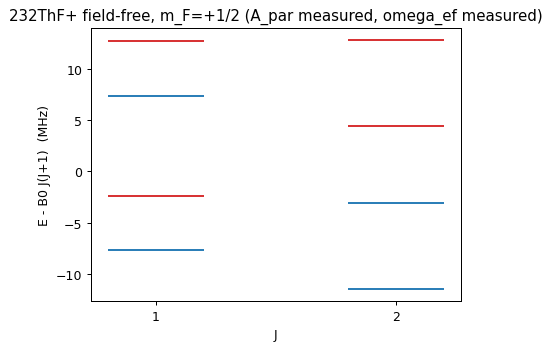

blue = e, red = f -- e lies BELOW f at every J (OPEN-2, resolved).


In [3]:
kets232, blocks232, ctx232, tm232 = load('232')
pset232 = thf_v2('232')
H0_232 = hamiltonian(tm232, pset232, {'E_z': 0.0, 'B_z': 0.0})
w232, v232 = np.linalg.eigh(H0_232)
lab232 = label_lines(kets232, v232, ctx232.S, rule=pset232.conventions.ef_rule, ell=0.0, s=0.0)

OFF232 = 2.0 * pset232.value('B0')
print("232ThF+, m_F = +1/2 block, E - 2B0 (MHz):")
for s in range(len(w232)):
    l = lab232[s]
    if l['J'] > 2:
        continue
    print(f"  E[{s}] = {w232[s] - OFF232:12.5f}   J={l['J']:.0f} F={l['F']:.1f} {l['ef']}"
          f" (parity {l['parity']:+d})")

fig, ax = plt.subplots(figsize=(5, 4))
for s in range(len(w232)):
    l = lab232[s]
    if l['J'] > 2:
        continue
    e = w232[s] - OFF232 if l['J'] == 1 else w232[s] - 6 * pset232.value('B0')
    ax.hlines(e, l['J'] - 0.2, l['J'] + 0.2, color='C0' if l['ef'] == 'e' else 'C3')
ax.set_xticks([1, 2])
ax.set_xlabel('J')
ax.set_ylabel('E - B0 J(J+1)  (MHz)')
ax.set_title('232ThF+ field-free, m_F=+1/2 (A_par measured, omega_ef measured)')
plt.tight_layout()
plt.show()
print("blue = e, red = f -- e lies BELOW f at every J (OPEN-2, resolved).")

## 4. ²²⁹ and ²²⁷ThF⁺ level diagrams, side by side with ²³²

The thorium hyperfine structure sets a much larger energy scale. For ²²⁹ at
J = 1, its spread is ~4.6 GHz, or 63 % of B₀ ([TH] §4.1). We therefore plot
²²⁹/²²⁷ on a separate axis, still relative to `B₀ J(J+1)`. Each F₁ manifold
contains ¹⁹F hyperfine and Ω-doubling substructure at the kHz–MHz scale. Every
eigenvalue is plotted, but this substructure is unresolved: the visible lines
effectively mark the F₁ centroids.

`A_par_Th` (²²⁹) is ab-initio with an unresolved sign (OPEN-16, §5).
For ²²⁷Th, `A_par_Th` = +39.8 GHz is a Schmidt stress-test placeholder for the tentative (1/2⁺) assignment, not a calibrated moment prediction. The separate [field plots](../results/thf-fields-2026-09-08/README.md) use Minkov et al.'s +1.79 GHz nuclear-theory alternative. This notebook keeps the stress-test value. ²²⁷Th (I = 1/2) has no quadrupole moment ([HAM] §9.6, OPEN-20). For ²³², `A_par` and `omega_ef` are measured (§3).

The ²²⁷ "J = 1" label identifies the dominant component of a mixed state.
Its eight selected eigenvectors carry as little as 0.63 of
their weight on J = 1 kets (median 0.81; ²²⁹ carries at least 0.994), because at
the placeholder `A∥ = +39.8 GHz` the Th hyperfine ΔJ = ±1 element is 0.59 ×
the rotational spacing ([HAM] §9.6). That strong ΔJ = ±1 mixing also explains
why the eigenvalue spread below (16.6 GHz) sits well below §9.6's first-order
estimate of +29.9 GHz against `4B₀ = 29.1 GHz`. At this placeholder value,
first-order perturbation theory in the Th hyperfine is not valid.

232ThF+ J=1 spread = 20.3376 MHz   J=1 weight min/median = 1.000/1.000


229ThF+ J=1 spread = 4.641 GHz  (63.8% of B0)   J=1 weight min/median = 0.994/0.997   A_par_Th status='ab-initio'
227ThF+ J=1 spread = 16.626 GHz  (228.6% of B0)   J=1 weight min/median = 0.629/0.814   A_par_Th status='placeholder'


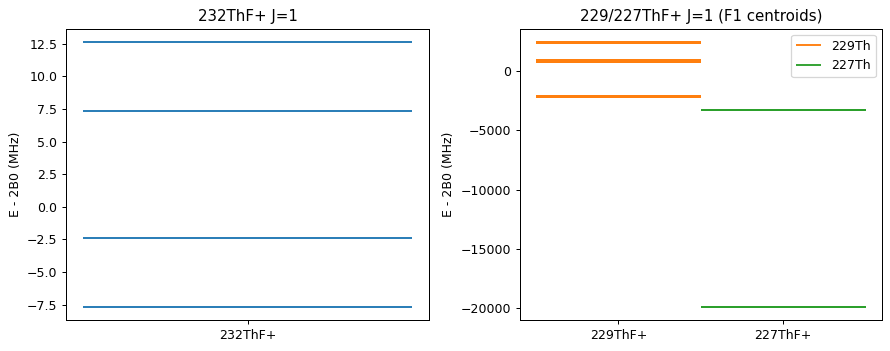

Both panels' x-axes are categorical (one column per isotopologue); individual hlines are plotted, but within one F1 manifold the 19F hyperfine/Omega-doubling substructure (kHz-MHz) is far below the GHz scale here, so only F1 centroids are visually distinguishable.


In [4]:
# Eigenvector columns whose DOMINANT basis component has J = 1, and the J = 1
# WEIGHT each of them actually carries (sum of |amplitude|^2 over every J = 1
# ket). The two are not the same statement: 'J = 1' below is an argmax LABEL,
# and the weight says how much of the state that label describes.
def dominant_J1(kets, v):
    dom = kets['J'][np.argmax(np.abs(v), axis=0)]
    sel = np.flatnonzero(dom == 1)
    wt = (np.abs(v[:, sel]) ** 2)[kets['J'] == 1].sum(axis=0)
    return sel, wt


def level_spread_J1(iso):
    kets, blocks, ctx, tm = load(iso)
    pset = thf_v2(iso)
    H0 = hamiltonian(tm, pset, {'E_z': 0.0, 'B_z': 0.0})
    w, v = np.linalg.eigh(H0)
    sel, wt = dominant_J1(kets, v)
    w1 = w[sel]
    return kets, w, v, sel, wt, w1.min(), w1.max(), w1.max() - w1.min()


fig, axes = plt.subplots(1, 2, figsize=(10, 4))

_, w232b, _, sel232, wt232, lo232, hi232, spread232 = level_spread_J1('232')
OFF = 2 * pset232.value('B0')
axes[0].hlines(w232b[sel232] - OFF, 0.8, 1.2)
axes[0].set_title('232ThF+ J=1')
print(f"232ThF+ J=1 spread = {spread232:.4f} MHz   "
      f"J=1 weight min/median = {wt232.min():.3f}/{np.median(wt232):.3f}")
axes[0].set_ylabel('E - 2B0 (MHz)')
axes[0].set_xticks([1.0])
axes[0].set_xticklabels(['232ThF+'])

colors = {'229': 'C1', '227': 'C2'}
for iso in ('229', '227'):
    kets, w, v, sel, wt, lo, hi, spread = level_spread_J1(iso)
    OFFi = 2 * thf_v2(iso).value('B0')
    axes[1].hlines((w[sel] - OFFi), 0.8 if iso == '229' else 1.2,
                   1.2 if iso == '229' else 1.6, color=colors[iso], label=f'{iso}Th')
    status = thf_v2(iso).params['A_par_Th'].status
    print(f"{iso}ThF+ J=1 spread = {spread/1e3:.3f} GHz  "
          f"({spread/pset229.value('B0')*100:.1f}% of B0)   "
          f"J=1 weight min/median = {wt.min():.3f}/{np.median(wt):.3f}   "
          f"A_par_Th status={status!r}")
axes[1].legend()
axes[1].set_title('229/227ThF+ J=1 (F1 centroids)')
axes[1].set_ylabel('E - 2B0 (MHz)')
axes[1].set_xticks([1.0, 1.4])
axes[1].set_xticklabels(['229ThF+', '227ThF+'])
plt.tight_layout()
plt.show()
print("Both panels' x-axes are categorical (one column per isotopologue); "
      "individual hlines are plotted, but within one F1 manifold the 19F "
      "hyperfine/Omega-doubling substructure (kHz-MHz) is far below the "
      "GHz scale here, so only F1 centroids are visually distinguishable.")

## 5. Reversing the ¹⁹F doublet ordering

Once `I_Th ≠ 0`, the ¹⁹F doublet splitting inside each `F₁` is no longer the
one-spin `A∥^F (2J+1)/[2J(J+1)]` law. It depends on `F₁` and can reverse sign
([TH] §4.5). We evaluate the diagonal projection of `hyperfine_A_par_F`, in
units of `A∥^F`, on the default branch
`thf_v2('229')` (`A_par_Th = −1510 MHz`, the signed, ab-initio value
recommended by `docs/lit/lookup-apar-th-sign-convention.md`). The alternative
branch is `thf_v2('229', a_par_th_sign='positive')`, trusting Denis 2015
instead of Skripnikov & Titov 2015. The sign of A∥(Th) is unresolved (OPEN-16).
We draw one branch because the ¹⁹F splitting pattern follows from recoupling
and is independent of that sign. Changing A∥_Th's sign changes the F₁ ordering,
and hence where each pattern appears in energy.

In [5]:
kets229, blocks229, ctx229, tm229 = load('229')
idxF = tm229.names.index('hyperfine_A_par_F')
mask1 = (kets229['J'] == 1) & (kets229['Om'] == 1)
rows = sorted(zip(kets229['F1'][mask1], kets229['F'][mask1], np.flatnonzero(mask1)))
diag = {(F1, F): tm229.mats[idxF][i, i] for F1, F, i in rows}

print("19F doublet splitting at J=1, in units of A_par^F (hyperfine_A_par_F term, diagonal):")
print(f"{'F1':>5}  {'E(F=F1+1/2)-E(F=F1-1/2)':>26}   (I_Th=0 reference: +0.7500)")
for F1 in sorted({F1 for F1, F in diag}):
    hi = diag[(F1, F1 + 0.5)]
    lo = diag[(F1, F1 - 0.5)]
    print(f"{F1:5.1f}  {hi - lo:26.4f}")

print()
print("A_par_Th status:", pset229.params['A_par_Th'].status,
      " value:", pset229.value('A_par_Th'), "MHz  (sign UNVERIFIED, OPEN-16)")
print("Alternative branch: thf_v2('229', a_par_th_sign='positive') trusts Denis 2015,",
      "+1510 MHz instead of the default -1510 MHz.")

19F doublet splitting at J=1, in units of A_par^F (hyperfine_A_par_F term, diagonal):
   F1     E(F=F1+1/2)-E(F=F1-1/2)   (I_Th=0 reference: +0.7500)
  1.5                     -0.4000
  2.5                      0.1714
  3.5                      0.5714

A_par_Th status: ab-initio  value: -1510.0 MHz  (sign UNVERIFIED, OPEN-16)
Alternative branch: thf_v2('229', a_par_th_sign='positive') trusts Denis 2015, +1510 MHz instead of the default -1510 MHz.


## 6. The eQq₂ versus ω_ef scale comparison

`eQq2_Th` mixes `Ω = +1 ↔ −1` at fixed `(J, F₁, F, m_F)`, in the same matrix
slot as `omega_doubling` ([HAM] §9.4.4, [TH] §4.4). Tabulated below at the
native eQq2_Th = 300 MHz placeholder (`status='placeholder'`, OPEN-17:
the signed normalization and magnitude are uncalibrated) against two reference scales: the
Ω-doubling off-diagonal element `ω_ef J(J+1)/4 = 2.65 MHz` at J = 1, and the
fully-polarised Stark shift `γ_F m_F d_mf E = 50.9 MHz` at F = 3/2, m_F = 3/2,
E = 60 V/cm (the JILA operating field, [HAM] §2.7). The latter is the ²³²-basis
(`I_Th = 0`) F = 3/2, m_F = 3/2 value, used here only as a familiar scale
against which to size the ²²⁹ quadrupole/Ω-doubling competition, not a ²²⁹
quantity itself. With this placeholder, the Stark and quadrupole scales are
comparable at the JILA field, so neither can be neglected in the comparison
with Ω-doubling ([TH] §4.4).

229ThF+, J=1, Omega=+1 <-> -1 mixing element (MHz):
   F1     F   omega_doubling    eQq2_Th (300 MHz)    ratio
  1.5   1.0           2.6450              51.4393    19.45
  1.5   2.0           2.6450              51.4393    19.45
  2.5   2.0           2.6450             -58.7878   -22.23
  2.5   3.0           2.6450             -58.7878   -22.23
  3.5   3.0           2.6450              18.3712     6.95
  3.5   4.0           2.6450              18.3712     6.95


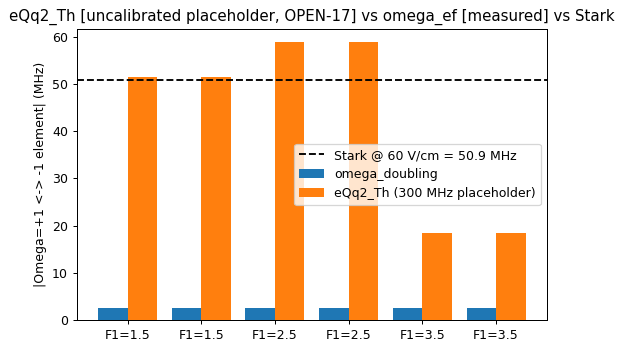


omega_ef J(J+1)/4 at J=1 = 2.645 MHz  [omega_ef: measured]
eQq2_Th is 6.9-22.2x the omega-doubling element for this 300 MHz placeholder scenario; this ratio is not a physical bound.


In [6]:
from heff.assemble import coefficients

idx_om = tm229.names.index('omega_doubling')
idx_q2 = tm229.names.index('quadrupole_eQq2_Th')
c229 = coefficients(tm229, pset229, {'E_z': 0.0, 'B_z': 0.0})

maskJ1 = kets229['J'] == 1
mask_p1 = maskJ1 & (kets229['Om'] == 1)
mask_m1 = maskJ1 & (kets229['Om'] == -1)
rows = []
for i in np.flatnonzero(mask_p1):
    F1, F = kets229['F1'][i], kets229['F'][i]
    for j in np.flatnonzero(mask_m1):
        if kets229['F1'][j] == F1 and kets229['F'][j] == F:
            om = c229[idx_om] * tm229.mats[idx_om][i, j]
            q2 = c229[idx_q2] * tm229.mats[idx_q2][i, j]
            rows.append((F1, F, om, q2))

print(f"229ThF+, J=1, Omega=+1 <-> -1 mixing element (MHz):")
print(f"{'F1':>5} {'F':>5} {'omega_doubling':>16} {'eQq2_Th (300 MHz)':>20} {'ratio':>8}")
for F1, F, om, q2 in rows:
    print(f"{F1:5.1f} {F:5.1f} {om:16.4f} {q2:20.4f} {q2 / om:8.2f}")

d_mf = pset229.value('d_mf')
gam = lambda J, F, I=0.5: (J * (J + 1) + F * (F + 1) - I * (I + 1)) / (2 * F * (F + 1) * J * (J + 1))
stark_60 = gam(1, 1.5) * 1.5 * d_mf * 60.0

fig, ax = plt.subplots(figsize=(6, 4))
labels = [f"F1={F1:g}" for F1, F, om, q2 in rows]
ax.bar(np.arange(len(rows)) - 0.2, [abs(om) for *_, om, q2 in rows], width=0.4, label='omega_doubling')
ax.bar(np.arange(len(rows)) + 0.2, [abs(q2) for *_, om, q2 in rows], width=0.4, label='eQq2_Th (300 MHz placeholder)')
ax.axhline(stark_60, ls='--', c='k', label=f'Stark @ 60 V/cm = {stark_60:.1f} MHz')
ax.set_xticks(range(len(rows)))
ax.set_xticklabels(labels)
ax.set_ylabel('|Omega=+1 <-> -1 element| (MHz)')
ax.set_title('eQq2_Th [uncalibrated placeholder, OPEN-17] vs omega_ef [measured] vs Stark')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nomega_ef J(J+1)/4 at J=1 = {pset229.value('omega_ef') * 2 / 4:.3f} MHz  [omega_ef: measured]")
print(f"eQq2_Th is {min(abs(q2/om) for *_, om, q2 in rows):.1f}-{max(abs(q2/om) for *_, om, q2 in rows):.1f}x "
      "the omega-doubling element for this 300 MHz placeholder scenario; this ratio is not a physical bound.")

## 7. J convergence

`j_convergence('229')` and `j_convergence('227')` at `J_max = 2, 4, 6`
(field-free; the helper selects `m_F = 0` for both,
since `F`/`m_F` are integer for both). The Th `ΔJ = ±1` hyperfine is a
~2 GHz off-diagonal element ([TH] §4.2) whose second-order shift is not
absorbable into `B₀`, because it depends on `F₁` (unlike the analogous ¹⁹F
term). `J_max` is a `StateSpec` setting (OPEN-22). The figures use `J_max = 4`;
use the table to assess that cutoff for these parameters and field-free states.

In [7]:
for iso in ('229', '227'):
    report = j_convergence(iso, J_maxes=(2, 4, 6))
    print(f"{iso}ThF+  (m_F = {report['mF']}, field-free):")
    print(f"  {'J_max':>6} {'dimension':>10} {'max shift vs J_max=6 (MHz)':>28}")
    for J_max, row in report['by_J_max'].items():
        print(f"  {J_max:6d} {row['dimension']:10d} {row['max_shift_MHz']:28.6g}")
    print()

print("The J_max=1 -> 4 jump, at the full J=1 dimension (V23's own demonstration):")
for iso, mF in (('229', 0.0), ('227', 0.0)):
    kets1, blocks1, _, _ = load(iso, J_max=1)
    n1 = len(blocks1.index[mF])
    r = j_convergence(iso, J_maxes=(1, 4), mF=mF, n_levels=n1)
    print(f"  {iso}ThF+: {r['by_J_max'][1]['max_shift_MHz']/1e3:.3f} GHz "
          f"({'Schmidt stress test, A_par_Th = +39.8 GHz' if iso == '227' else 'ab-initio A_par_Th'})")

229ThF+  (m_F = 0.0, field-free):
   J_max  dimension   max shift vs J_max=6 (MHz)
       2         32                       3.7915
       4         80                  3.81783e-05
       6        128                            0



227ThF+  (m_F = 0.0, field-free):
   J_max  dimension   max shift vs J_max=6 (MHz)
       2         16                   0.00145934
       4         32                            0
       6         48                            0

The J_max=1 -> 4 jump, at the full J=1 dimension (V23's own demonstration):


  229ThF+: 0.179 GHz (ab-initio A_par_Th)
  227ThF+: 13.256 GHz (Schmidt stress test, A_par_Th = +39.8 GHz)


## 8. Zeeman maps and g-factors

We evaluate Hellmann–Feynman g-factors with `observe.g_factors`, using one
non-zero signed-`m_F` block per isotopologue: `m_F = +1/2` for ²³² (matches the
tutorial's block), `m_F = +1` for ²²⁹/²²⁷ (smallest non-zero integer m_F).
Predicted g at J > 1 rests on `G_perp = (G_xx + G_yy)/2`, which carries the
rotational g-factor and comes from Petrov's second-order sums at roughly 20 %
rather than from a fit ([HAM] §2.8, §2.10, OPEN-7). Only the measured
combination `G_zz + G_perp` is anchored, at J = 1, F = 3/2 for ²³², so the same
caveat applies to every g below. All J = 1 states
of the chosen `m_F` block are plotted below, with one panel per isotopologue.

These curves use the parameter choices in §4–§6: ab-initio magnetic hyperfine
for ²²⁹, uncalibrated ²²⁹ quadrupoles, and the ²²⁷ Schmidt stress test.
Thorium spin rotation is held at zero for missing input (OPEN-19).

232ThF+ (m_F=0.5): g at J=1 (4 states, all distinct) = [-0.032935 -0.032387 -0.015039 -0.014765]
229ThF+ (m_F=1): g at J=1 (12 states, all distinct) = [-0.008606 -0.008502 -0.006055 -0.005974 -0.004517 -0.004445 -0.002387 -0.002338  0.007399  0.007488  0.010389
  0.010529]
227ThF+ (m_F=1): g at J=1 (6 states, all distinct) = [-0.014222 -0.013948 -0.012018 -0.011914 -0.006074 -0.006012]


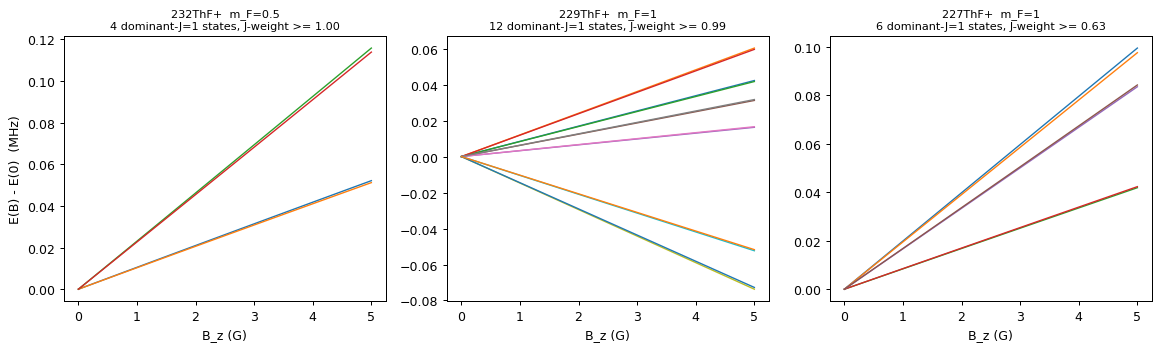

In [8]:
gblocks = {}
for iso, mF in (('232', 0.5), ('229', 1.0), ('227', 1.0)):
    kets, blocks, ctx, tm = load(iso, mF=mF)
    pset = thf_v2(iso)
    gblocks[iso] = (kets, ctx, tm, pset, mF)

B = np.linspace(0.0, 5.0, 51)
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=True)
for ax, iso in zip(axes, ISOTOPOLOGUES):
    kets, ctx, tm, pset, mF = gblocks[iso]
    res0 = g_factors(tm, pset, {'E_z': 0.0, 'B_z': 0.0}, ctx=ctx)
    # select EIGENVECTORS by their dominant component, not basis kets by their
    # J field -- for 227 the two are not interchangeable (see the 4 caption).
    _, v0 = np.linalg.eigh(hamiltonian(tm, pset, {'E_z': 0.0, 'B_z': 0.0}))
    j1, wt1 = dominant_J1(kets, v0)
    gblocks[iso] = gblocks[iso] + (j1, wt1)
    g_j1 = res0['g'][j1]
    g_unique = np.unique(np.round(g_j1, 6))
    n_states, n_unique = len(j1), len(g_unique)
    degen_note = (f" ({n_unique} unique of {n_states} states -- "
                  f"{n_states - n_unique} exactly degenerate pair(s))"
                  if n_unique < n_states else f" ({n_states} states, all distinct)")
    print(f"{iso}ThF+ (m_F={mF:g}): g at J=1{degen_note} = {g_unique}")
    r = sweep(tm, pset, {'E_z': np.zeros_like(B), 'B_z': B})
    for s in j1:
        ax.plot(B, r.evals[:, s] - r.evals[0, s], lw=1.1)
    ax.set_title(f'{iso}ThF+  m_F={mF:g}\n{n_states} dominant-J=1 states, '
                 f'J-weight >= {wt1.min():.2f}', fontsize=9)
    ax.set_xlabel('B_z (G)')
axes[0].set_ylabel('E(B) - E(0)  (MHz)')
plt.tight_layout()
plt.show()

## 9. Stark maps

The three isotopologues' `m_F` blocks from §8 (`m_F = +1/2` for ²³², `+1` for
²²⁹/²²⁷), swept in `E_z`. The ²³² panel draws the `F = 1/2` linear-limit
closed form `|Ω m_F γ_F(F=1/2) d_mf E|` as a dashed reference curve. The
²²⁹/²²⁷ panels have no such closed form because the Th hyperfine mixes many
more `(F₁, F)` states at comparable energy, so only the direct
diagonalisation is shown for them. Even on the ²³² panel, the exact
curves visibly exceed this linear-limit reference by 60 V/cm: the closed
form assumes `F = 1/2` and `F = 3/2` stay decoupled, but the ¹⁹F hyperfine
splitting between them (`15 MHz` at J = 1) is comparable to, not much larger
than, the Stark shift at the top of the sweep (`~40 MHz`), so the two `F`
manifolds mix and the exact eigenvalues depart from the linear-limit formula.

These curves use the parameter choices in §4–§6: ab-initio magnetic hyperfine
for ²²⁹, uncalibrated ²²⁹ quadrupoles, and the ²²⁷ Schmidt stress test.
Thorium spin rotation is held at zero for missing input (OPEN-19).

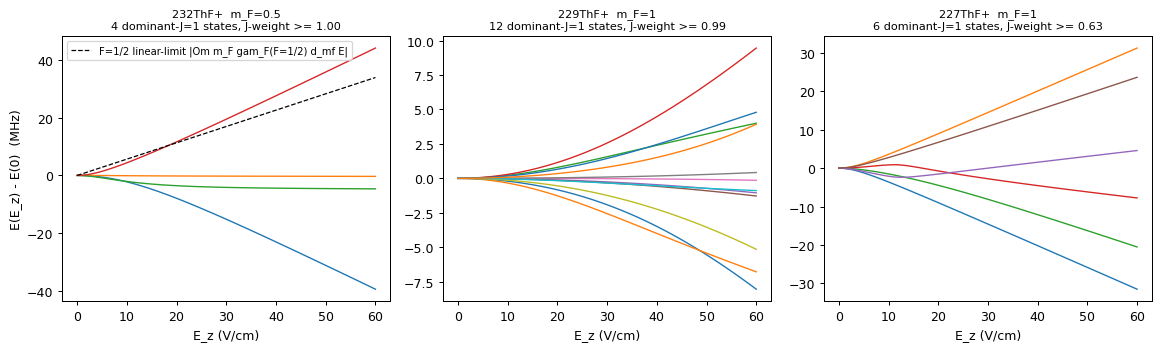

In [9]:
E = np.linspace(0.0, 60.0, 61)
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=True)
gam = lambda J, F, I=0.5: (J * (J + 1) + F * (F + 1) - I * (I + 1)) / (2 * F * (F + 1) * J * (J + 1))

for ax, iso in zip(axes, ('232', '229', '227')):
    kets, ctx, tm, pset, mF, j1, wt1 = gblocks[iso]
    r = sweep(tm, pset, {'E_z': E, 'B_z': np.zeros_like(E)})
    for s in j1:
        ax.plot(E, r.evals[:, s] - r.evals[0, s], lw=1.1)
    ax.set_title(f'{iso}ThF+  m_F={mF:g}\n{len(j1)} dominant-J=1 states, '
                 f'J-weight >= {wt1.min():.2f}', fontsize=9)
    ax.set_xlabel('E_z (V/cm)')

axes[0].set_ylabel('E(E_z) - E(0)  (MHz)')
d_mf = pset232.value('d_mf')
closed = np.abs(1.0 * 0.5 * gam(1, 0.5) * d_mf * E)
axes[0].plot(E, closed, 'k--', lw=1, label='F=1/2 linear-limit |Om m_F gam_F(F=1/2) d_mf E|')
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 10. One-photon E1 spectra

Two adjacent `m_F` blocks per isotopologue, each diagonalised separately at
zero field, then `heff.spectra.line_strengths` (v1 geometry for ²³²,
`functools.partial(heff.elements_c2.axial_geometry, k=1, q=0.0)` for
²²⁹/²²⁷) between them, with only a single σ⁻ polarisation
(`polarizations=(-1,)`) driven. This shows which `(J, F₁, F)` transitions
are geometrically allowed and their relative strengths, though the absolute
strengths would differ under σ⁺ or an unpolarised sum. Lines are filtered by
`J` into within J = 1 (`ΔJ = 0`, same-Ω dipole transitions that only
exist because both `Ω = ±1` mix inside one `m_F` block) and J = 1 ↔ 2;
the strongest ~6 lines per panel are printed with their full
`(J, F₁, F, parity)` labels from `label_lines`.

The `J` used to sort lines into the two rows is `label_lines`' dominant
component, so on the ²²⁷ panels "J = 1" means a dominant-J=1 assignment
carrying as little as 0.63 J = 1 weight, median 0.81 (§4), not a J eigenstate; ΔJ there is a
label difference, not a selection rule.

These curves use the parameter choices in §4–§6: ab-initio magnetic hyperfine
for ²²⁹, uncalibrated ²²⁹ quadrupoles, and the ²²⁷ Schmidt stress test.
Thorium spin rotation is held at zero for missing input (OPEN-19).

Single polarisation shown throughout: sigma- (polarizations=(-1,)).
232ThF+ within J=1: 4 lines above 1e-6 of the strongest, strongest 4 shown:
    J=1 F=1.5 parity=-1  ->  J=1 F=1.5 parity=+1   S=0.167
    J=1 F=1.5 parity=+1  ->  J=1 F=1.5 parity=-1   S=0.167
    J=1 F=0.5 parity=+1  ->  J=1 F=1.5 parity=-1   S=0.0832
    J=1 F=0.5 parity=-1  ->  J=1 F=1.5 parity=+1   S=0.0832
232ThF+ J=1 -> 2: 6 lines above 1e-6 of the strongest, strongest 6 shown:
    J=1 F=0.5 parity=-1  ->  J=2 F=1.5 parity=+1   S=0.25
    J=1 F=0.5 parity=+1  ->  J=2 F=1.5 parity=-1   S=0.25
    J=1 F=1.5 parity=-1  ->  J=2 F=2.5 parity=+1   S=0.18
    J=1 F=1.5 parity=+1  ->  J=2 F=2.5 parity=-1   S=0.18
    J=1 F=1.5 parity=+1  ->  J=2 F=1.5 parity=-1   S=0.02
    J=1 F=1.5 parity=-1  ->  J=2 F=1.5 parity=+1   S=0.02


229ThF+ within J=1: 51 lines above 1e-6 of the strongest, strongest 6 shown:
    J=1 F1=3.5 F=4.0 parity=+1  ->  J=1 F1=3.5 F=4.0 parity=-1   S=0.184
    J=1 F1=3.5 F=4.0 parity=-1  ->  J=1 F1=3.5 F=4.0 parity=+1   S=0.184
    J=1 F1=3.5 F=3.0 parity=+1  ->  J=1 F1=3.5 F=3.0 parity=-1   S=0.182
    J=1 F1=3.5 F=3.0 parity=-1  ->  J=1 F1=3.5 F=3.0 parity=+1   S=0.182
    J=1 F1=1.5 F=1.0 parity=-1  ->  J=1 F1=2.5 F=2.0 parity=+1   S=0.101
    J=1 F1=1.5 F=1.0 parity=+1  ->  J=1 F1=2.5 F=2.0 parity=-1   S=0.1
229ThF+ J=1 -> 2: 60 lines above 1e-6 of the strongest, strongest 6 shown:
    J=1 F1=1.5 F=2.0 parity=+1  ->  J=2 F1=1.5 F=2.0 parity=-1   S=0.101
    J=1 F1=1.5 F=2.0 parity=-1  ->  J=2 F1=1.5 F=2.0 parity=+1   S=0.1
    J=1 F1=3.5 F=3.0 parity=-1  ->  J=2 F1=4.5 F=4.0 parity=+1   S=0.0991
    J=1 F1=3.5 F=3.0 parity=+1  ->  J=2 F1=4.5 F=4.0 parity=-1   S=0.099
    J=1 F1=3.5 F=4.0 parity=-1  ->  J=2 F1=4.5 F=5.0 parity=+1   S=0.0951
    J=1 F1=3.5 F=4.0 parity=+1  ->  J=2 F1=4.5 

227ThF+ within J=1: 22 lines above 1e-6 of the strongest, strongest 6 shown:
    J=1 F1=0.5 F=0.0 parity=-1  ->  J=1 F1=1.5 F=1.0 parity=+1   S=0.19
    J=1 F1=0.5 F=0.0 parity=+1  ->  J=1 F1=1.5 F=1.0 parity=-1   S=0.19
    J=1 F1=0.5 F=1.0 parity=-1  ->  J=1 F1=1.5 F=2.0 parity=+1   S=0.142
    J=1 F1=0.5 F=1.0 parity=+1  ->  J=1 F1=1.5 F=2.0 parity=-1   S=0.142
    J=1 F1=0.5 F=1.0 parity=-1  ->  J=1 F1=0.5 F=1.0 parity=+1   S=0.111
    J=1 F1=0.5 F=1.0 parity=+1  ->  J=1 F1=0.5 F=1.0 parity=-1   S=0.111
227ThF+ J=1 -> 2: 20 lines above 1e-6 of the strongest, strongest 6 shown:
    J=1 F1=1.5 F=1.0 parity=+1  ->  J=2 F1=2.5 F=2.0 parity=-1   S=0.166
    J=1 F1=1.5 F=1.0 parity=-1  ->  J=2 F1=2.5 F=2.0 parity=+1   S=0.165
    J=1 F1=1.5 F=2.0 parity=+1  ->  J=2 F1=2.5 F=3.0 parity=-1   S=0.147
    J=1 F1=1.5 F=2.0 parity=-1  ->  J=2 F1=2.5 F=3.0 parity=+1   S=0.147
    J=1 F1=0.5 F=0.0 parity=+1  ->  J=2 F1=1.5 F=1.0 parity=-1   S=0.0324
    J=1 F1=0.5 F=0.0 parity=-1  ->  J=2 F1=1.5

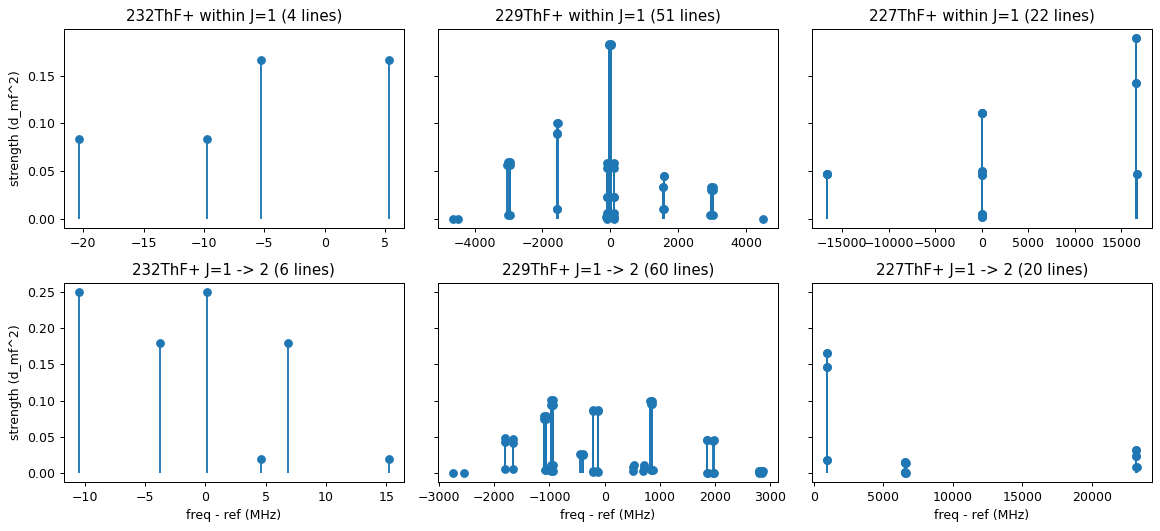

In [10]:
import functools
from heff.elements_c2 import axial_geometry

GEO = functools.partial(axial_geometry, k=1, q=0.0)


def e1_spectrum(iso, mF_a, mF_b):
    kets_a, _, ctx, tm_a = load(iso, mF=mF_a)
    kets_b, _, _, tm_b = load(iso, mF=mF_b)
    pset = thf_v2(iso)
    wa, va = np.linalg.eigh(hamiltonian(tm_a, pset, {'E_z': 0.0, 'B_z': 0.0}))
    wb, vb = np.linalg.eigh(hamiltonian(tm_b, pset, {'E_z': 0.0, 'B_z': 0.0}))
    geo = None if iso == '232' else GEO
    freqs, S = line_strengths(wa, va, kets_a, wb, vb, kets_b, ctx,
                              polarizations=(-1,), weights={-1: 1.0}, geometry=geo)
    lab_a = label_lines(kets_a, va, ctx.S, rule=pset.conventions.ef_rule, ell=0.0, s=0.0)
    lab_b = label_lines(kets_b, vb, ctx.S, rule=pset.conventions.ef_rule, ell=0.0, s=0.0)
    return freqs, S, lab_a, lab_b


def fmt_lab(lab):
    F1s = f"F1={lab['F1']:.1f} " if 'F1' in lab else ''
    return f"J={lab['J']:.0f} {F1s}F={lab['F']:.1f} parity={lab['parity']:+d}"


PAIRS = {'232': (0.5, 1.5), '229': (0.0, 1.0), '227': (0.0, 1.0)}
print("Single polarisation shown throughout: sigma- (polarizations=(-1,)).")
fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharey='row')
for col, iso in enumerate(('232', '229', '227')):
    mFa, mFb = PAIRS[iso]
    freqs, S, lab_a, lab_b = e1_spectrum(iso, mFa, mFb)
    mask = S > 1e-6 * S.max()
    ia, ib = np.nonzero(mask)
    for row, (Jsel_a, Jsel_b, title) in enumerate(
            [(1, 1, 'within J=1'), (1, 2, 'J=1 -> 2')]):
        sel = [(i, j) for i, j in zip(ia, ib)
               if lab_a[i]['J'] == Jsel_a and lab_b[j]['J'] == Jsel_b]
        sel.sort(key=lambda ij: -S[ij[0], ij[1]])
        f0 = 0.0 if Jsel_a == Jsel_b else 4 * thf_v2(iso).value('B0')
        xs = [freqs[i, j] - f0 for i, j in sel]
        ys = [S[i, j] for i, j in sel]
        if xs:
            axes[row, col].stem(xs, ys, basefmt=' ')
        axes[row, col].set_title(f'{iso}ThF+ {title} ({len(sel)} lines)')
        print(f"{iso}ThF+ {title}: {len(sel)} lines above 1e-6 of the strongest, "
              f"strongest {min(6, len(sel))} shown:")
        for i, j in sel[:6]:
            print(f"    {fmt_lab(lab_a[i])}  ->  {fmt_lab(lab_b[j])}   S={S[i, j]:.3g}")
    axes[1, col].set_xlabel('freq - ref (MHz)')
axes[0, 0].set_ylabel('strength (d_mf^2)')
axes[1, 0].set_ylabel('strength (d_mf^2)')
plt.tight_layout()
plt.show()

## 11. The two-photon operator

Adiabatic elimination of a far-detuned intermediate manifold gives, between
X-state levels, `T_eff = Σ_i (d·ε₂*) |i⟩⟨i| (d·ε₁) / Δ_i` ([HAM] §9.5, [2γ]
§3.1). With a common detuning, B&C Eq. (5.142) read backwards makes the
intermediate sum the reduced element of a single rank-K polarisability,
`α^K = T^K(d,d)/Δ`: one scalar per `(K, ΔΩ)` channel times parameter-free
geometry ([HAM] §9.5.1(1)). `heff` computes the geometry; `alphas` is the
caller's scalar per channel.

Two rank-1 dipole operators couple to `K = 0, 1, 2`
(B&C (5.141)). Within X ³Δ₁, `|Ω| = 1` on both sides, so `ΔΩ ∈ {0, ±2}`, and
`ΔΩ = ±2` needs `K = 2` and an `Ω = 0` intermediate state. Each E1 leg
carries `|q_i| ≤ 1`, and only an `Ω_i = 0` intermediate lets the two legs sum
to `ΔΩ = ±2` ([2γ] §3.3). `K = 1` is not registered: in *exact closure*
(a complete opposite-parity intermediate manifold) it is the antisymmetric
part of the dyad, proportional to `P_X [d_a, d_b] P_X`, which is identically
zero because the Cartesian components of the dipole commute. This is confirmed
numerically to `2.2 × 10⁻¹⁶` on a complete spherical-harmonic closure test
([HAM] §9.5.3, OPEN-21 resolved: `K ∈ {0, 2}` only, registered; `K = 1`
reappears only at `O(δ/Δ)` in the resolved sum or `O(1)` for a *restricted*
intermediate manifold; neither is in this operator).

The operator is parity-even: `P d P† = −d` twice. At zero
field, where `P` commutes with `H`, this means the two-photon operator
connects `e → e` and `f → f` and never `e ↔ f` ([2γ] §3.3). At non-zero
`E_rot` parity is not a good quantum number (the Stark term does not commute
with `P`), and the e/f restriction lifts. JILA operates in this regime.

The allowed projections are `Δm_F ∈ {0, ±1, ±2}`, never ±3. The Wigner-Eckart
projection bounds `|Δm_F| ≤ K ≤ 2` ([HAM] §9.5.4). This is why the two-photon
operator is not the eEDM π/2 pulse (`Δm_F = ±3` within J = 1, `|m_F| =
3/2 → ∓3/2`): that transfer is done by an `E_rot` amplitude ramp, not by
2 × E1 ([2γ] §1 row 4).

Closure requires `Δ ≫ B_i ≈ 7 GHz` for ThF⁺, where `B_i` is the intermediate
electronic state's rotational constant (`B_e ≈ 0.23 cm⁻¹`). The JILA
experiments use detunings of 0.16–1.5 GHz, outside this limit ([HAM] §9.5.5).
To model those experiments quantitatively, we would need a resolved sum with
the intermediate ladder and its 0⁺/0⁻ labels specified.

The `alpha_K*_dOm*` scalars below are placeholders (`status='placeholder'`,
value 1.0 in their unit): no ThF⁺ two-photon polarisability exists in any
source summarized in [2γ] (gap 1). The spectra in §12–13 therefore illustrate
the relative strengths allowed by the rank-K geometry and polarisation dyad.
They do not predict physical rates.

## 12. Two-photon spectra within J = 1 and J = 1 ↔ 2

Same two `m_F` blocks as §10, now driven by `two_photon_line_strengths` at
`alphas = 1` for every registered channel (`alpha_K0_dOm0`, `alpha_K2_dOm0`,
`alpha_K2_dOm2`, all `placeholder`). We use three polarisation pairs in the
ladder reading (both photons absorbed, `Δm_F = p1 + p2`, [HAM] §9.5.1(3)):
`(σ⁺, σ⁺) → Δm_F = +2`, `(σ⁺, σ⁻) → Δm_F = 0`, `(σ⁻, σ⁻) → Δm_F = −2`.

The frequency and `Δm_F` signs need care. The amplitude is `⟨bra|T|ket⟩`
with the ket the initial state and the bra the final one (`T_P` raises the
ket's `m_F` by `P = p₁ + p₂`; gate 1 of `tests/test_transition.py`), and
`Δm_F = m_bra − m_ket` (`axial_geometry`'s `P = bra_mF − ket_mF`).
`freqs[i, j]` below is `E_ket[j] − E_bra[i]` (`heff.spectra._strengths_from_matrices`'s
own convention, reused unchanged by `two_photon_line_strengths`), i.e.
`E_initial − E_final = −(ω₁ + ω₂)`. In the J = 1 → 2 panels the bra-side
block is the J = 1 states and the ket-side block reaches into J = 2, so the
amplitude computed is literally `⟨J=1|T|J=2⟩`; at zero field this equals the
J = 1 → 2 strength for the conjugate pair by `m_F → −m_F` symmetry, so the
panels are direction-agnostic here. A positive `freq` means the J = 2 (ket)
state sits above the J = 1 (bra) state.

Ng discusses opposite helicities in his thesis (p. 102):
"An alternative to the π-polarized microwaves is to use a two-photon Raman
process, using photons of opposite helicities. We would need to do some
spectroscopy to make this happen." His stated target
`|J=1,F=3/2,m_F=+3/2⟩ → |m_F=+1/2⟩` is `Δm_F = −1` and is out of reach
with σ± alone. `m_F = +3/2 → −1/2` is `Δm_F = −2`, reached by a
same-helicity `σ⁻σ⁻` pair (`[2γ] §3.3`, marked there as derived, not
something JILA has stated it intends).

229ThF+ (sig+,sig+) dmF=+2 within J=1: 58 lines
229ThF+ (sig+,sig+) dmF=+2 J=1->2: 86 lines


229ThF+ (sig+,sig-) dmF=0 within J=1: 24 lines (12 diagonal i=f light-shift element(s) excluded)
229ThF+ (sig+,sig-) dmF=0 J=1->2: 55 lines


229ThF+ (sig-,sig-) dmF=-2 within J=1: 58 lines
229ThF+ (sig-,sig-) dmF=-2 J=1->2: 86 lines


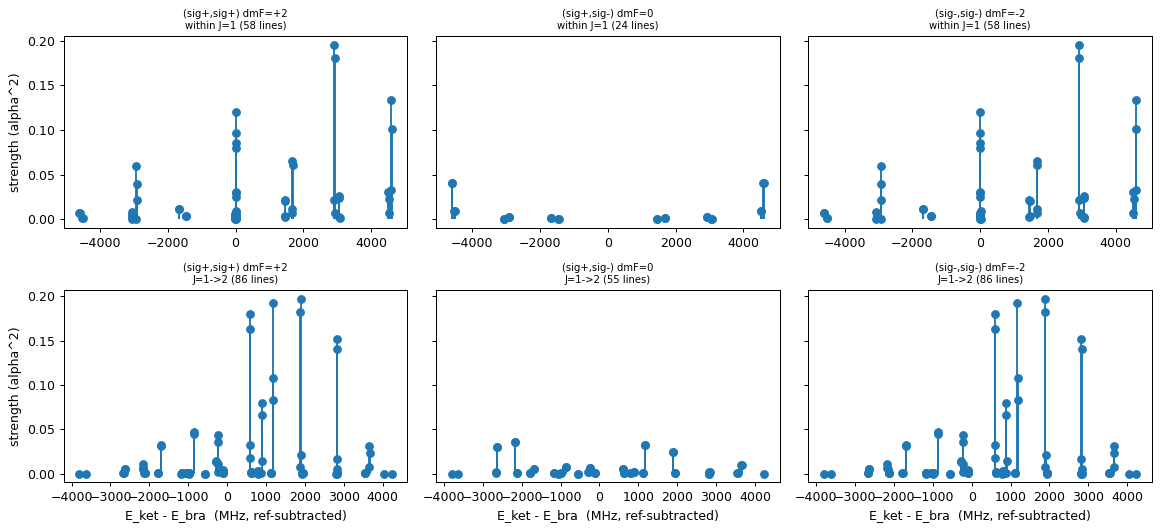

In [11]:
SQ2 = np.sqrt(2.0)
SIGMA_P = np.array([-1.0, -1.0j, 0.0]) / SQ2
SIGMA_M = np.array([1.0, -1.0j, 0.0]) / SQ2
ALPHAS = {'alpha_K0_dOm0': 1.0, 'alpha_K2_dOm0': 1.0, 'alpha_K2_dOm2': 1.0}

# label -> (eps1, eps2, Delta m_F).  Ladder reading (both photons absorbed,
# Delta m_F = p1 + p2, [HAM] S9.5.1(3) row (d)). two_photon_spectrum's first
# block argument is the BRA side and the second is the KET side
# (two_photon_matrix(kets_a, kets_b, ...) evaluates two_photon_geometry(
# kets_a[i], kets_b[j], ...), whose bra/ket order matches axial_geometry:
# Delta m_F = P = bra_mF - ket_mF), so the bra-side block sits at
# ket_mF + Delta m_F. Picking the wrong pair gives an all-zero spectrum,
# not an error, so this mapping is the load-bearing part.
TWOP_PAIRS = {'(sig+,sig+) dmF=+2': (SIGMA_P, SIGMA_P, 2),
             '(sig+,sig-) dmF=0': (SIGMA_P, SIGMA_M, 0),
             '(sig-,sig-) dmF=-2': (SIGMA_M, SIGMA_M, -2)}


# 232ThF+ padded into the KET_C2 dtype at I_Th=0 (V16: ket-for-ket identical
# to the v1 basis, tests/test_elements_c2_reduction.py; gate 8 of test_transition.py).
from heff.transition import padded_thf


def two_photon_spectrum(iso, mF_a, mF_b, eps1, eps2):
    """Diagonalise the mF_a (BRA side) and mF_b (KET side) blocks
    separately (field-free) and return the two-photon line list between
    them, geometry only (alphas = 1 for every registered channel -- the
    alphas are placeholders, so the strengths below are geometry, not rate).
    The physical Delta m_F of the transition is mF_a - mF_b.
    """
    if iso == '232':
        kets2, ctx, _, _ = padded_thf('232', J_max=J_MAX)
        blocks2 = block_by_mF(kets2)
        kets_a, kets_b = kets2[blocks2.index[mF_a]], kets2[blocks2.index[mF_b]]
        tm_a = build_term_matrices(kets_a, ctx, case='c2', registry=REGISTRY_C2)
        tm_b = build_term_matrices(kets_b, ctx, case='c2', registry=REGISTRY_C2)
    else:
        kets_a, _, ctx, tm_a = load(iso, mF=mF_a)
        kets_b, _, _, tm_b = load(iso, mF=mF_b)
    pset = thf_v2(iso)
    wa, va = np.linalg.eigh(hamiltonian(tm_a, pset, {'E_z': 0.0, 'B_z': 0.0}))
    wb, vb = np.linalg.eigh(hamiltonian(tm_b, pset, {'E_z': 0.0, 'B_z': 0.0}))
    freqs, S = two_photon_line_strengths(wa, va, kets_a, wb, vb, kets_b, ctx,
                                         eps1=eps1, eps2=eps2, alphas=ALPHAS)
    lab_a = label_lines(kets_a, va, ctx.S, rule=pset.conventions.ef_rule, ell=0.0, s=0.0)
    lab_b = label_lines(kets_b, vb, ctx.S, rule=pset.conventions.ef_rule, ell=0.0, s=0.0)
    return freqs, S, lab_a, lab_b


mF0_229 = 0.0
fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharey='row')
for col, (label, (eps1, eps2, dmF)) in enumerate(TWOP_PAIRS.items()):
    freqs, S, lab_a, lab_b = two_photon_spectrum('229', mF0_229 + dmF, mF0_229, eps1, eps2)
    mask = S > 1e-9 * max(S.max(), 1e-30)
    ia, ib = np.nonzero(mask)
    for row, (Ja, Jb, title) in enumerate([(1, 1, 'within J=1'), (1, 2, 'J=1->2')]):
        sel = [(i, j) for i, j in zip(ia, ib) if lab_a[i]['J'] == Ja and lab_b[j]['J'] == Jb]
        n_diag = 0
        if dmF == 0 and Ja == Jb:
            # dmF=0 reuses the SAME mF block for bra and ket, so i==j is the
            # literal same eigenstate: a diagonal alpha^K=0 "light shift"
            # element, not a transition. Excluded from the transition panels
            # Reported separately below because it is a light shift, not a transition.
            n_diag = sum(1 for i, j in sel if i == j)
            sel = [(i, j) for i, j in sel if i != j]
        f0 = 0.0 if Ja == Jb else 4 * pset229.value('B0')
        if sel:
            axes[row, col].stem([freqs[i, j] - f0 for i, j in sel],
                                [S[i, j] for i, j in sel], basefmt=' ')
        axes[row, col].set_title(f'{label}\n{title} ({len(sel)} lines)', fontsize=8)
        print(f"229ThF+ {label} {title}: {len(sel)} lines"
              + (f" ({n_diag} diagonal i=f light-shift element(s) excluded)" if n_diag else ""))
    axes[1, col].set_xlabel('E_ket - E_bra  (MHz, ref-subtracted)')
axes[0, 0].set_ylabel('strength (alpha^2)')
axes[1, 0].set_ylabel('strength (alpha^2)')
plt.tight_layout()
plt.show()

## 13. Two-photon spectra, all three isotopologues

Same `(σ⁺, σ⁺)`, `Δm_F = +2`, within-J = 1 panel, for ²³², ²²⁹ and ²²⁷.
²³² needs the I_Th = 0 `KET_C2`-shaped basis (`heff.transition.padded_thf`) since
`axial_geometry`/`two_photon_geometry` require a two-spin `ctx`. The ²²⁹ and
²²⁷ panels are built on the same field-free Hamiltonian as every other
²²⁹/²²⁷ figure in this notebook, so the same status caveats apply here too:

These curves use the parameter choices in §4–§6: ab-initio magnetic hyperfine
for ²²⁹, uncalibrated ²²⁹ quadrupoles, and the ²²⁷ Schmidt stress test.
Thorium spin rotation is held at zero for missing input (OPEN-19).

232ThF+ within J=1, (sig+,sig+) dmF=+2: 4 lines


229ThF+ within J=1, (sig+,sig+) dmF=+2: 58 lines


227ThF+ within J=1, (sig+,sig+) dmF=+2: 8 lines


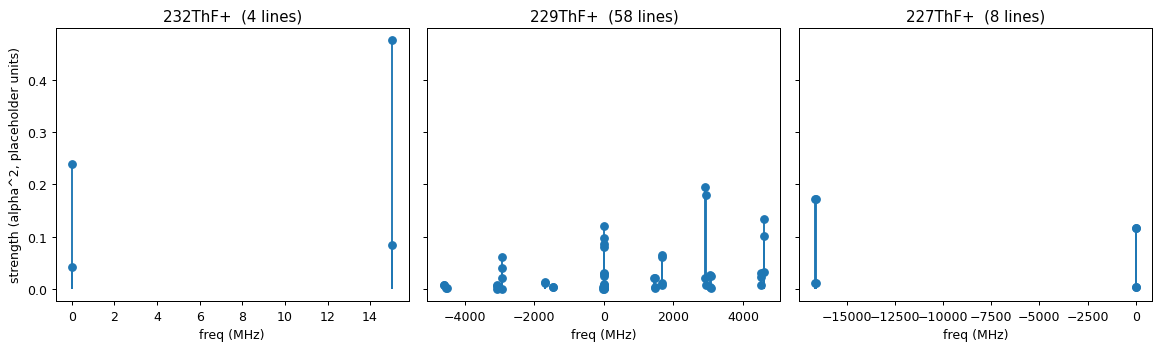

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, iso in zip(axes, ('232', '229', '227')):
    # 232's J=1 manifold only reaches |F| <= 1.5 (I_Th=0), so the ket-side
    # m_F has to sit at -0.5 (bra at +1.5) for both sides to have J=1 states
    # at Delta m_F=+2; 229/227 reach F=4 and F=2 respectively at J=1, so m_F=0
    # (bra at +2) already works.
    ket_mF = -0.5 if iso == '232' else 0.0
    freqs, S, lab_a, lab_b = two_photon_spectrum(iso, ket_mF + 2, ket_mF, SIGMA_P, SIGMA_P)
    mask = S > 1e-9 * max(S.max(), 1e-30)
    ia, ib = np.nonzero(mask)
    sel = [(i, j) for i, j in zip(ia, ib) if lab_a[i]['J'] == 1 and lab_b[j]['J'] == 1]
    if sel:
        ax.stem([freqs[i, j] for i, j in sel], [S[i, j] for i, j in sel], basefmt=' ')
    ax.set_title(f'{iso}ThF+  ({len(sel)} lines)')
    ax.set_xlabel('freq (MHz)')
    print(f"{iso}ThF+ within J=1, (sig+,sig+) dmF=+2: {len(sel)} lines")
axes[0].set_ylabel('strength (alpha^2, placeholder units)')
plt.tight_layout()
plt.show()

## 14. Model scope

The two-spin model adds or recouples the following terms: `hyperfine_A_par_Th`,
`hyperfine_A_par_Th_dJ1`, `spin_rotation_cI_Th`, `zeeman_nuclear_Th`,
`hyperfine_A_par_F`, `hyperfine_A_par_F_dJ1`, `spin_rotation_cI_F`,
`quadrupole_eQq0_Th`, `quadrupole_eQq2_Th`; the rank-K two-photon operator
(`REGISTRY_2G`, never summed into a Hamiltonian).

The model omits the following interactions (scales in [HAM] §5): `Ω = ±2, ±3` (³Δ₂, ³Δ₃);
`e_Δ` (hyperfine-dependent Ω-doubling, OPEN-8); the rotating-frame term
(`ħω_rot F_x`, breaks m_F blocking).

The physical limits are:

- `A∥(Th)` for ²²⁹Th: ab-initio, sign unresolved between two
  calculations that agree in magnitude (OPEN-16).
- `eQq₂_Th` and `eQq₀_Th` (parameters `eQq2_Th` and `eQq0_Th`) for ²²⁹Th: uncalibrated placeholders for
  sensitivity cases. Their signs, conversion, and magnitudes are not
  validated, and the displayed values are not uncertainty bounds
  (OPEN-17/OPEN-18).
- `c_I(Th)`: held at 0 because an input is missing (OPEN-19).
- For ²²⁷Th, `A_par_Th` = +39.8 GHz is a Schmidt stress-test placeholder for the tentative (1/2⁺) assignment, not a calibrated moment prediction. The separate [field plots](../results/thf-fields-2026-09-08/README.md) use Minkov et al.'s +1.79 GHz nuclear-theory alternative. This notebook keeps the stress-test value. ²²⁷Th (I = 1/2) has no quadrupole moment ([HAM] §9.6, OPEN-20).
- The two-photon `K = 1` channel is absent because exact closure makes it
  identically zero (OPEN-21; §11).
- `J_max`: a `StateSpec` knob, this notebook uses 4 throughout with a
  convergence table (§7; OPEN-22).
- The two-photon closure form: valid at `Δ ≫ 7 GHz`, JILA runs at
  0.16–1.5 GHz (OPEN-23).

The [scientific limitations](../docs/open-questions.md) discuss OPEN-16 through
OPEN-23 with their sources. Tests check the implementation, while these input
and approximation limits determine what the results can establish.